# Mobile Price Prediction Project
Complete EDA, Preprocessing, Feature Engineering


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('Processed_Flipdata - Processed_Flipdata.csv')
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [3]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [4]:
df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


In [20]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    object 
 1   Colour         541 non-null    object 
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    object 
 6   Front Camera   541 non-null    object 
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    object 
 10  Prize          541 non-null    object 
dtypes: float64(1), int64(4), object(6)
memory usage: 46.6+ KB


,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000
mean,110.550832,5.397412,4871.587800,0.062847,16.431201
std,60.600694,1.984923,780.148862,0.242911,2.523553
min,16.000000,2.000000,800.000000,0.000000,4.500000
25%,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,128.000000,8.000000,5000.000000,0.000000,16.940000
max,256.000000,8.000000,7000.000000,1.000000,41.940000


In [21]:
df.isnull().sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [5]:
df.columns = df.columns.str.strip().str.lower()

Convert Price to Numeric

In [6]:
df['prize'] = (
    df['prize']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
)

df['prize'] = pd.to_numeric(df['prize'], errors='coerce')

Handle Missing Values

In [7]:
# Numeric → median
df.fillna(df.median(numeric_only=True), inplace=True)

# Categorical → mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

Detect Outliers
Using Boxplot (visual)

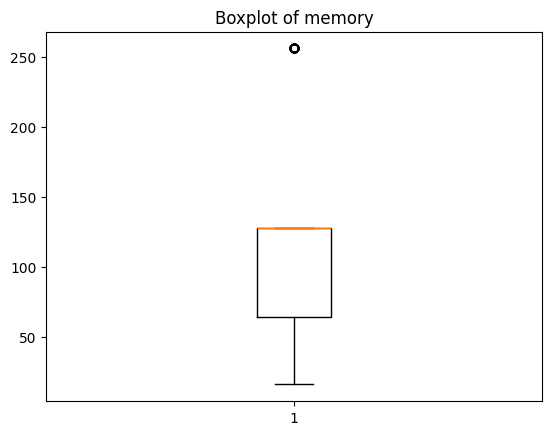

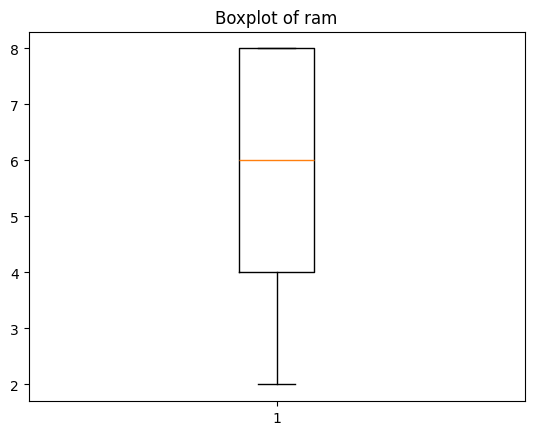

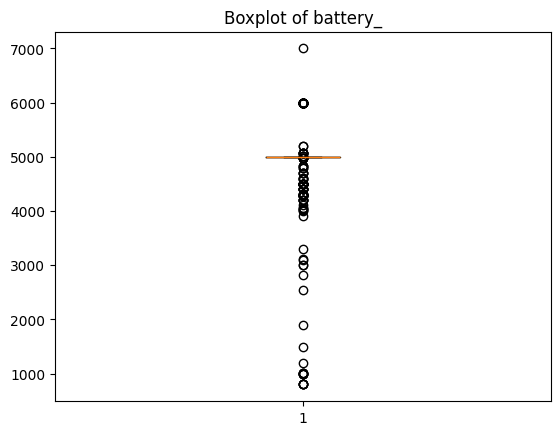

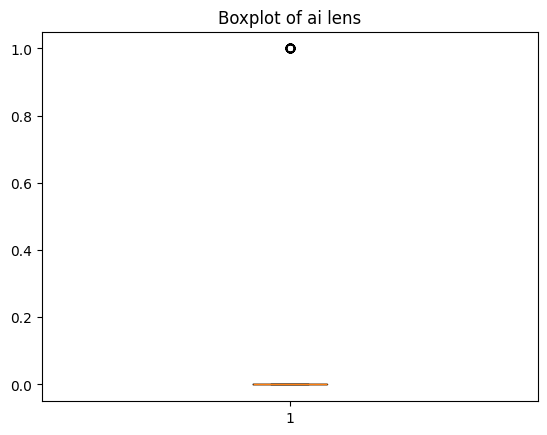

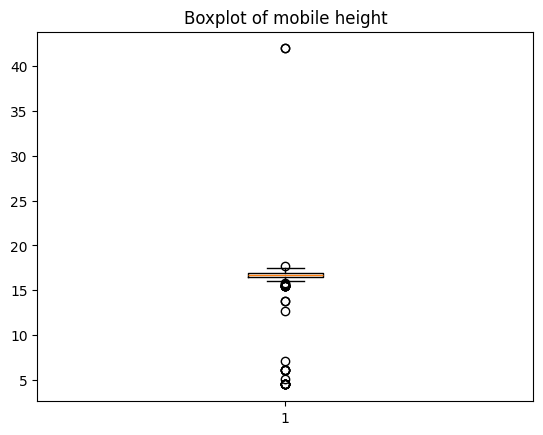

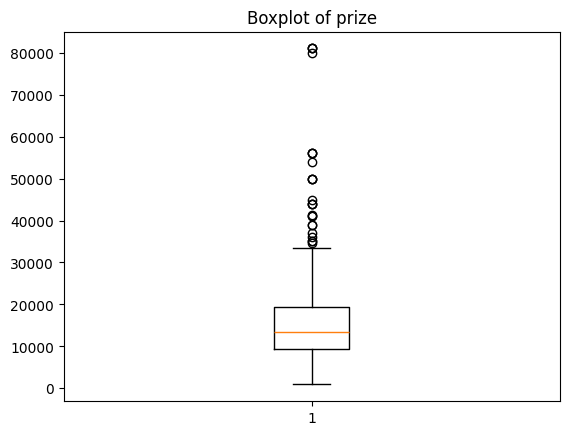

In [9]:
import matplotlib.pyplot as plt

for col in df.select_dtypes(include='number'):
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Using IQR (most common method)

In [10]:
Q1 = df['prize'].quantile(0.25)
Q3 = df['prize'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-5695.0 34265.0


Handle Outliers
Method: Capping

In [11]:
df['prize'] = np.where(df['prize'] < lower, lower, df['prize'])
df['prize'] = np.where(df['prize'] > upper, upper, df['prize'])

In [13]:
Q1 = df['prize'].quantile(0.25)
Q3 = df['prize'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Min:", df['prize'].min())
print("Max:", df['prize'].max())

print("Lower limit:", lower)
print("Upper limit:", upper)

Min: 920.0
Max: 34265.0
Lower limit: -5695.0
Upper limit: 34265.0


Checking if any outliers still exist

In [29]:
outliers = df[(df['prize'] < lower) | (df['prize'] > upper)]
print("Outliers remaining:", len(outliers))

Outliers remaining: 0


Visual Check (Boxplot)

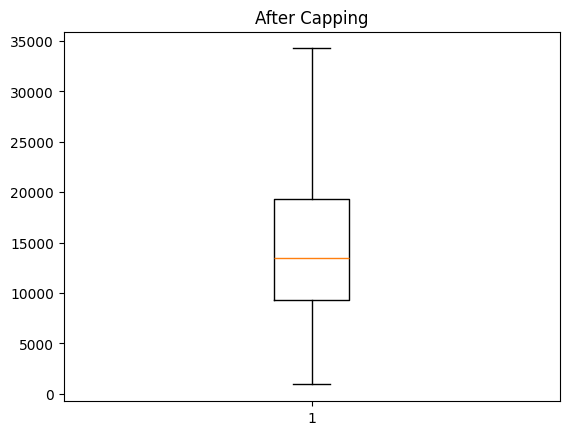

In [14]:
import matplotlib.pyplot as plt

plt.boxplot(df['prize'])

plt.title("After Capping")

plt.show()

Univariate Analysis

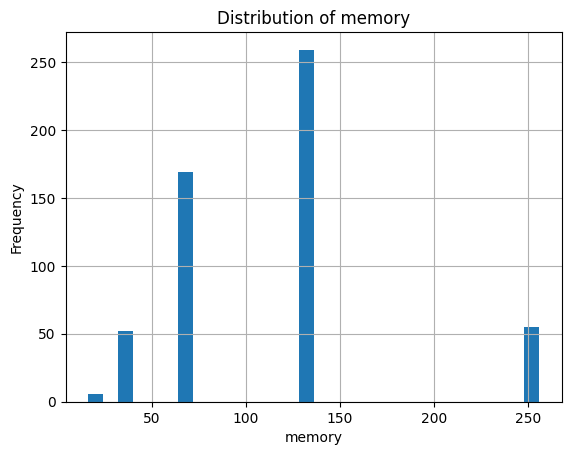

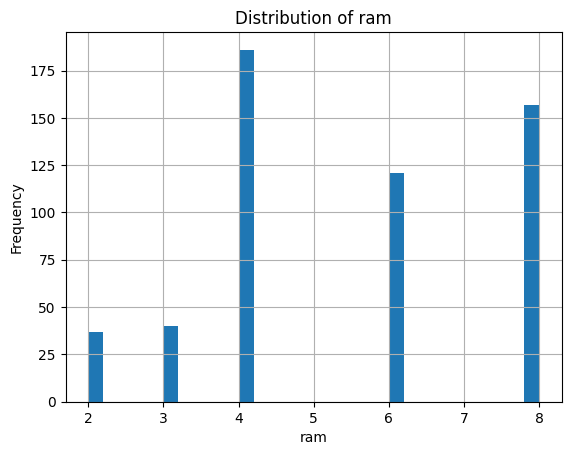

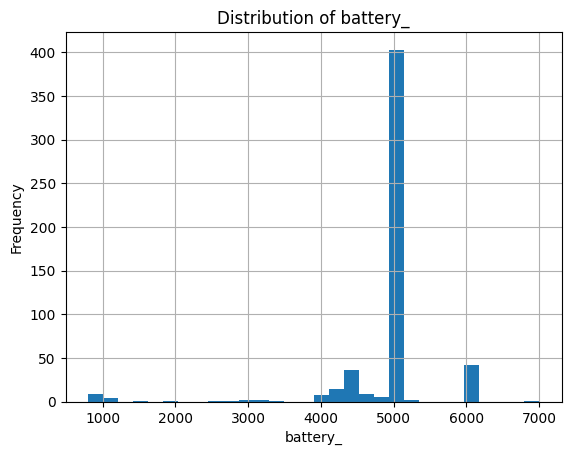

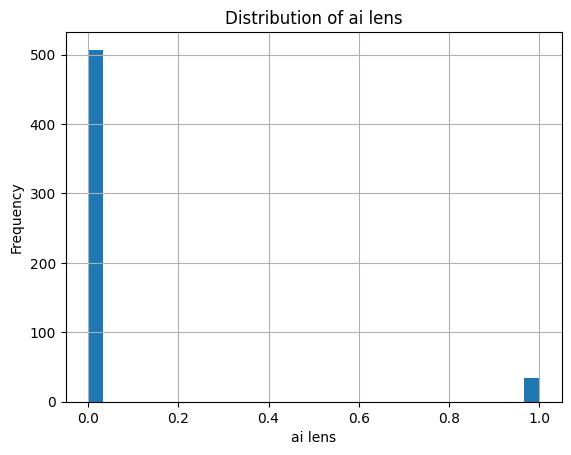

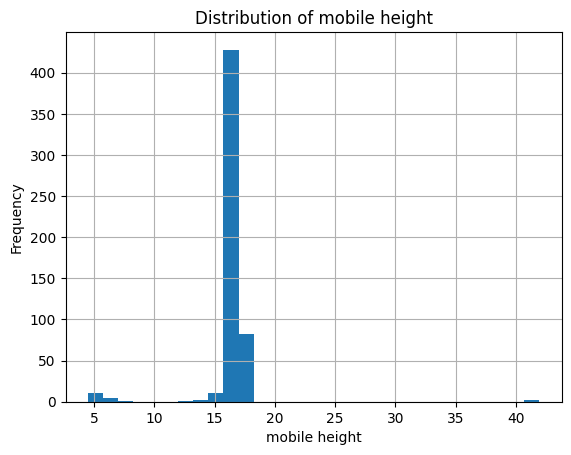

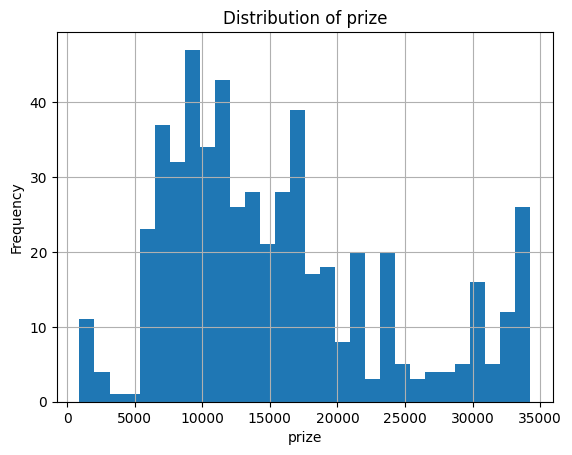

In [15]:
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

Bivariate Analysis

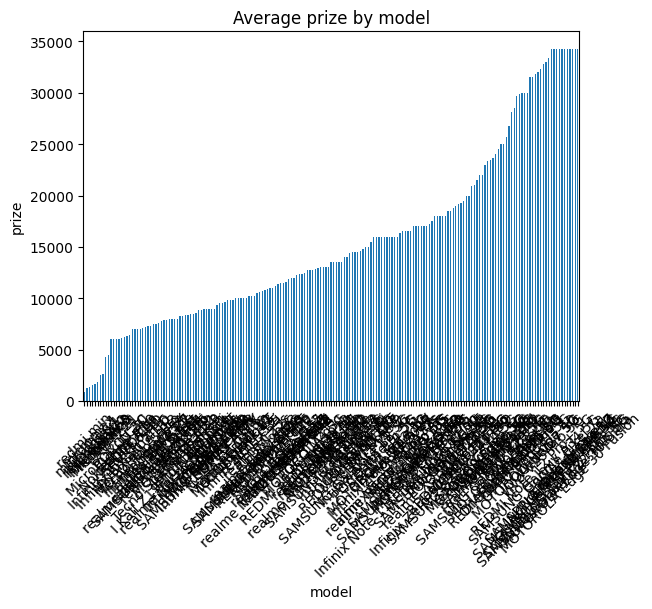

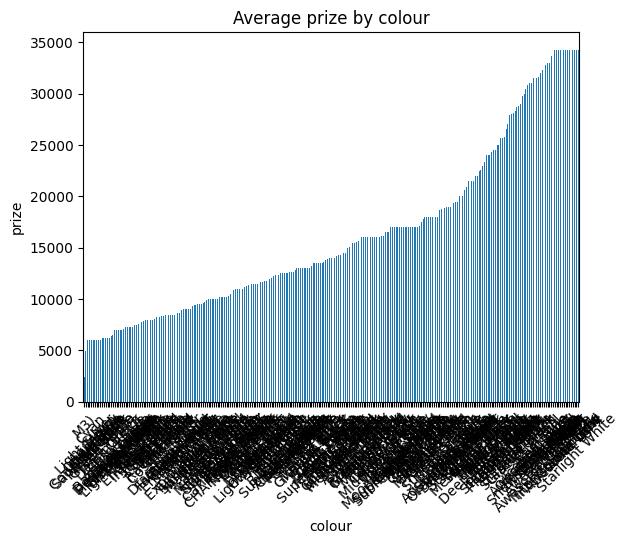

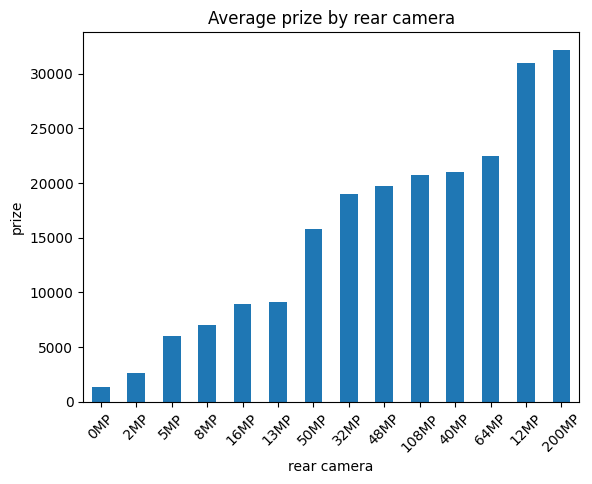

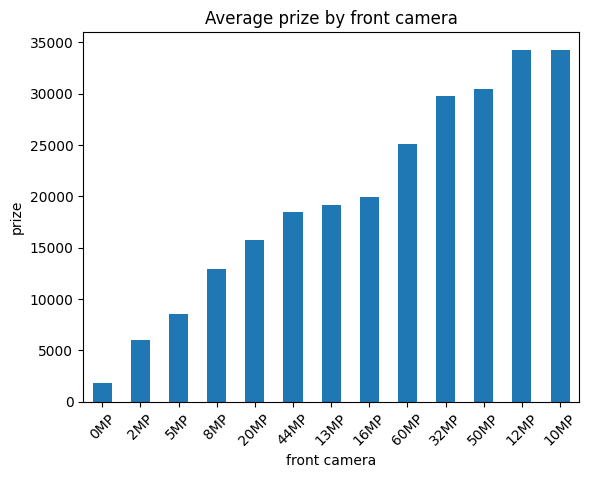

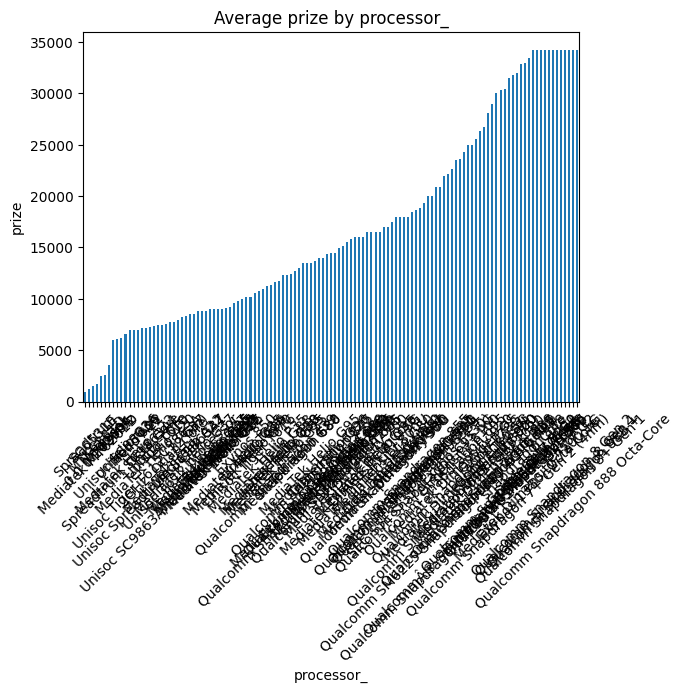

In [19]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    avg_prize = df.groupby(col)['prize'].mean().sort_values()

    plt.figure()
    avg_prize.plot(kind='bar')
    plt.title(f"Average prize by {col}")
    plt.ylabel("prize")
    plt.xticks(rotation=45)
    plt.show()

In [16]:
print(df.columns)

Index(['model', 'colour', 'memory', 'ram', 'battery_', 'rear camera',
       'front camera', 'ai lens', 'mobile height', 'processor_', 'prize'],
      dtype='object')


Multivariate Analysis

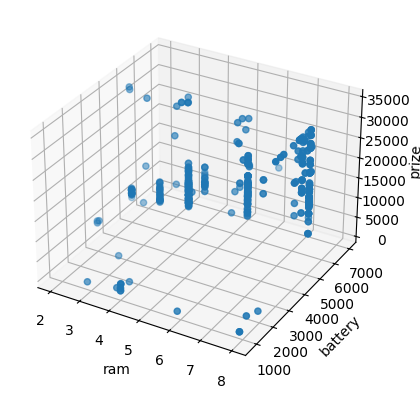

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['ram'], df['battery_'], df['prize'])

ax.set_xlabel('ram')
ax.set_ylabel('battery')
ax.set_zlabel('prize')

plt.show()

Convert Categorical Variables (Encoding)

In [20]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [22]:
# Target variable
y = df_encoded['prize']   # replace 'price' with your exact column name

# Features
X = df_encoded.drop('prize', axis=1)

Heatmap Visualization
Insight:
Values close to +1 → strong positive impact
Values close to -1 → strong negative impact
Near 0 → weak influence

👉 Typically important features:

RAM
Battery
Processor
Camera
Memory

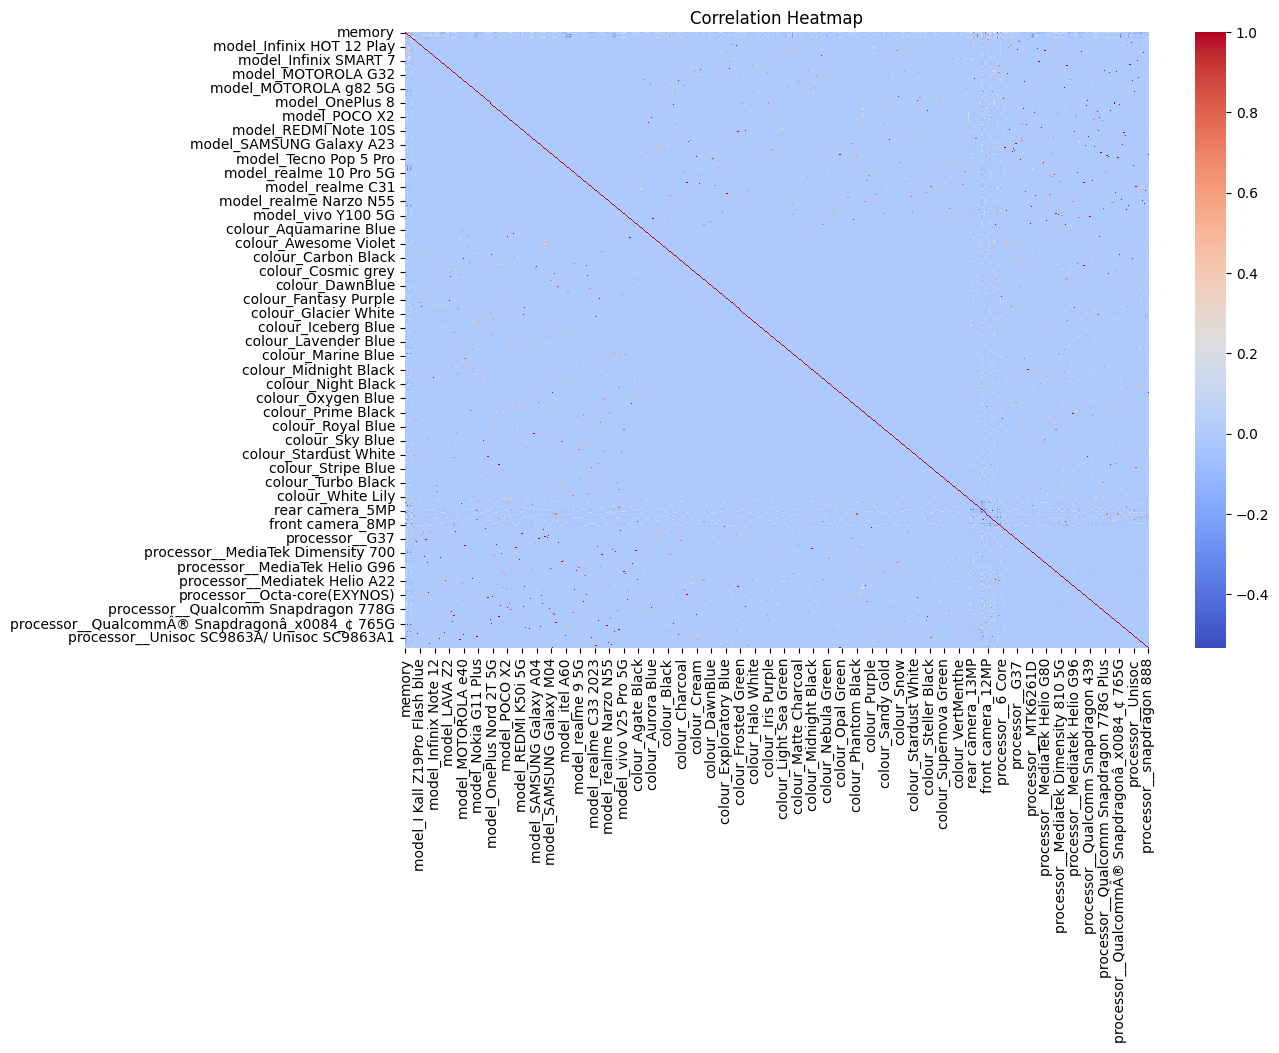

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Correlation Analysis (Statistical Method)

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr = df_encoded.corr()

# Correlation with price
prize_corr = corr['prize'].sort_values(ascending=False)
print(prize_corr)

prize                            1.000000
memory                           0.676775
ram                              0.651490
front camera_16MP                0.358981
front camera_32MP                0.357925
                                   ...   
processor__SC6531E              -0.195242
processor__Mediatek Helio A22   -0.207382
rear camera_13MP                -0.282774
rear camera_8MP                 -0.337393
front camera_5MP                -0.490267
Name: prize, Length: 613, dtype: float64


Top Features vs Price (Visual Analysis)
✅ Insight:
Upward trend → price increases with feature
Flat/no pattern → less important feature

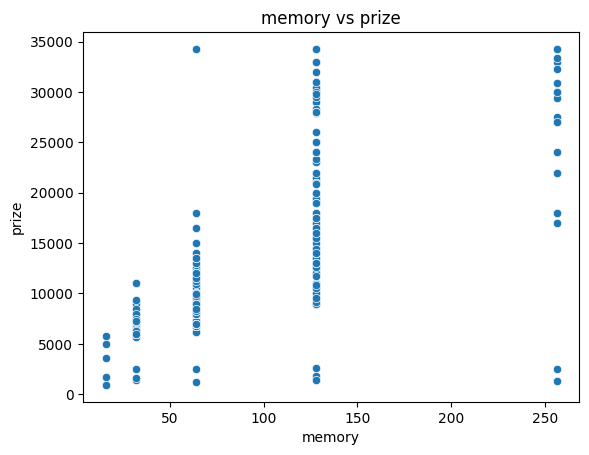

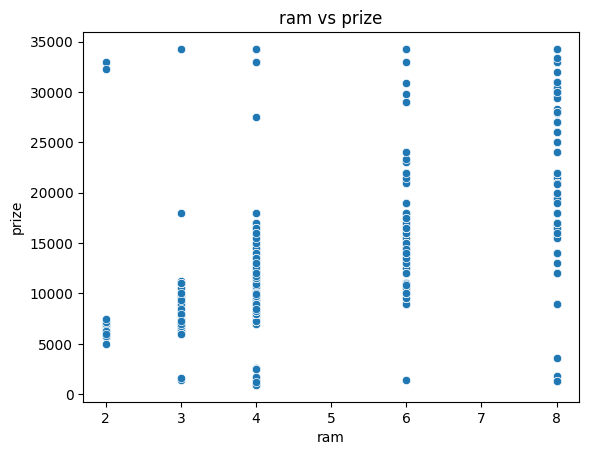

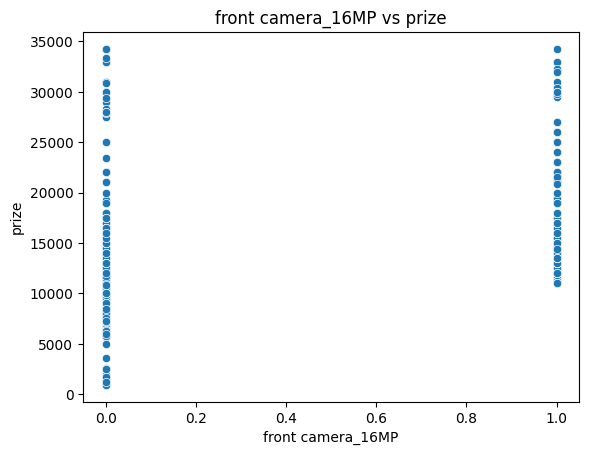

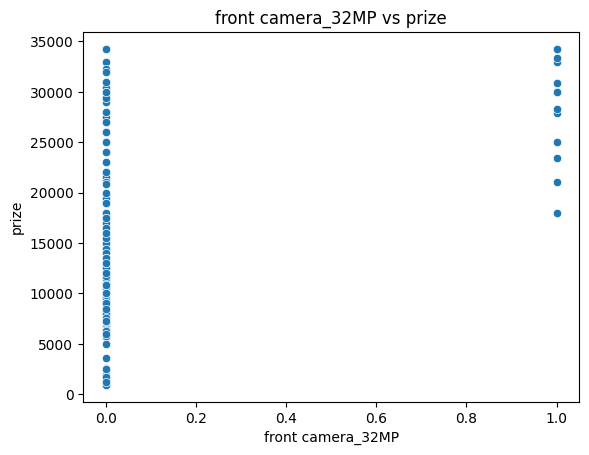

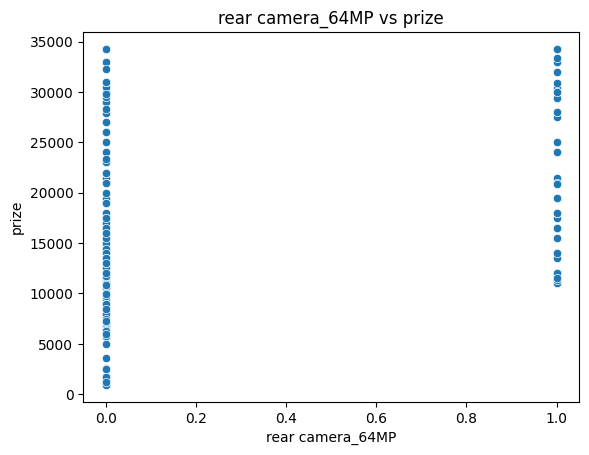

In [27]:
top_features = prize_corr.index[1:6]  # top 5 features (excluding price)

for col in top_features:
    plt.figure()
    sns.scatterplot(x=df_encoded[col], y=df_encoded['prize'])
    plt.title(f"{col} vs prize")
    plt.show()

    Feature & Target Split

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Feature Scaling (Important for ML models)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_

# Create importance dataframe
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp.head(10))

                         Feature  Importance
0                         memory    0.399119
2                       battery_    0.167359
1                            ram    0.113412
4                  mobile height    0.092118
487             front camera_5MP    0.019931
481            front camera_16MP    0.012841
484            front camera_32MP    0.012755
113  model_SAMSUNG Galaxy A34 5G    0.011031
479            front camera_12MP    0.009372
588           processor__SC6531E    0.009042


Plot Feature Importance

Insight:
Higher value = stronger influence on price
This is more reliable than correlation

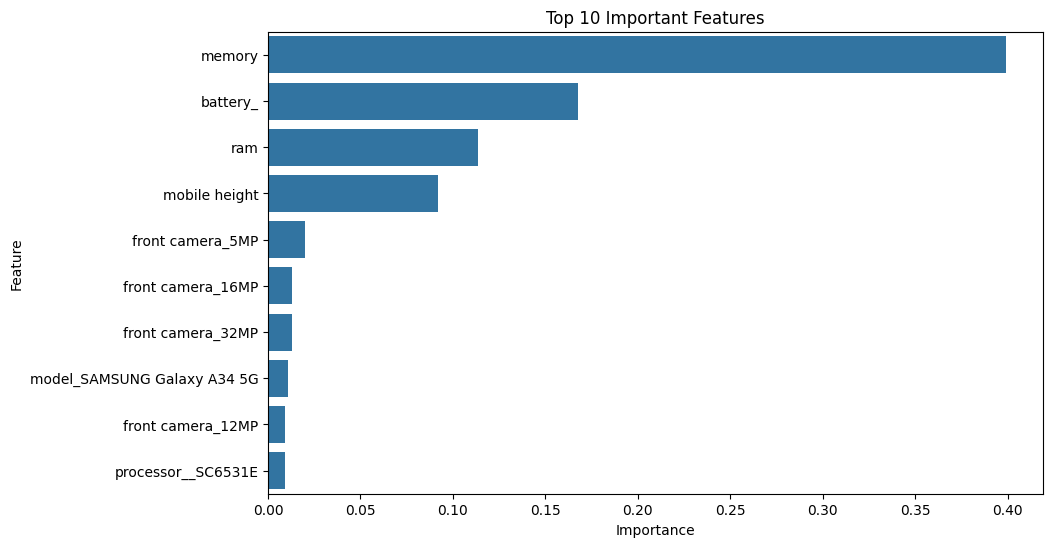

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.title("Top 10 Important Features")
plt.show()